In [1]:
# Gerekli Kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Çıktı ve Görselleştirme Ayarları
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid", palette="husl")

# Veri Setini Yükleme (Oğuzhan'ın temizlediği ana veriyi kullanıyoruz)
df = pd.read_csv('C:\\Users\\Monster\\Desktop\\deneme\\food-health-predictor\\data\\data.csv') # C:\\Users\\Monster\\Desktop\\deneme\\food-health-predictor\\data\\data.csv

# İlk Bakış
display(df.head())
print(f"Veri Seti Boyutu: {df.shape}")

,barkod,miktar,markalar,alerjenler,eser_miktarlar,icerik_sayisi,nutriscore_notu,nova_grubu,yesil_skor_notu,palmiye_yagi_icermez,vejetaryen,vegan_durumu,enerji_kcal,yag_g,doymus_yag_g,karbonhidrat_g,seker_g,lif_g,protein_g,tuz_g,alkol_yuzde,meyve_sebze_baklagil_yuzde,birim,kategori_listesi,etiketler_listesi
0,6.111247e+12,1.0,milky food professional,['Milk'],['Milk'],3.0,A,3.0,B,True,True,maybe,80.0,12.0,0.0,6.1,0.0,0.0,7.3,0.00000,0.0,NaN,kg,"['Dairies', 'Fermented foods', 'Fermented milk...",['Vegetarian']
1,6.111035e+12,33.0,سيدي علي,[],[],1.0,A,NaN,NaN,False,True,yes,0.0,0.0,0.0,4.2,1.4,0.0,0.0,0.00000,NaN,0.0,cl,"['Beverages and beverages preparations', 'Beve...",[]
2,6.111035e+12,1.5,sidi ali,[],[],1.0,A,1.0,NaN,True,True,yes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00760,NaN,0.0,l,"['Beverages and beverages preparations', 'Beve...","['ISO 22000', 'ISO 14001', 'ISO 45001', 'ISO 9..."
3,6.111035e+12,2.0,sidi ali,[],[],7.0,A,1.0,NaN,True,True,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.06500,NaN,NaN,l,"['Beverages and beverages preparations', 'Beve...",['Green Dot']
4,3.274080e+12,1500.0,cristaline,[],[],1.0,A,1.0,NaN,True,True,yes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00275,NaN,NaN,ml,"['Beverages and beverages preparations', 'Beve...",['Triman']


Veri Seti Boyutu: (64663, 25)


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64663 entries, 0 to 64662
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   barkod                      64662 non-null  float64
 1   miktar                      52485 non-null  float64
 2   markalar                    62414 non-null  str    
 3   alerjenler                  64663 non-null  str    
 4   eser_miktarlar              64663 non-null  str    
 5   icerik_sayisi               56569 non-null  float64
 6   nutriscore_notu             64604 non-null  str    
 7   nova_grubu                  55315 non-null  float64
 8   yesil_skor_notu             48007 non-null  str    
 9   palmiye_yagi_icermez        52774 non-null  object 
 10  vejetaryen                  50318 non-null  object 
 11  vegan_durumu                56899 non-null  str    
 12  enerji_kcal                 64050 non-null  float64
 13  yag_g                       64046 non-null

Temizleme oncesi: 64604 satir
Temizleme sonrasi: 60117 satir (4487 uc deger kaldirildi)


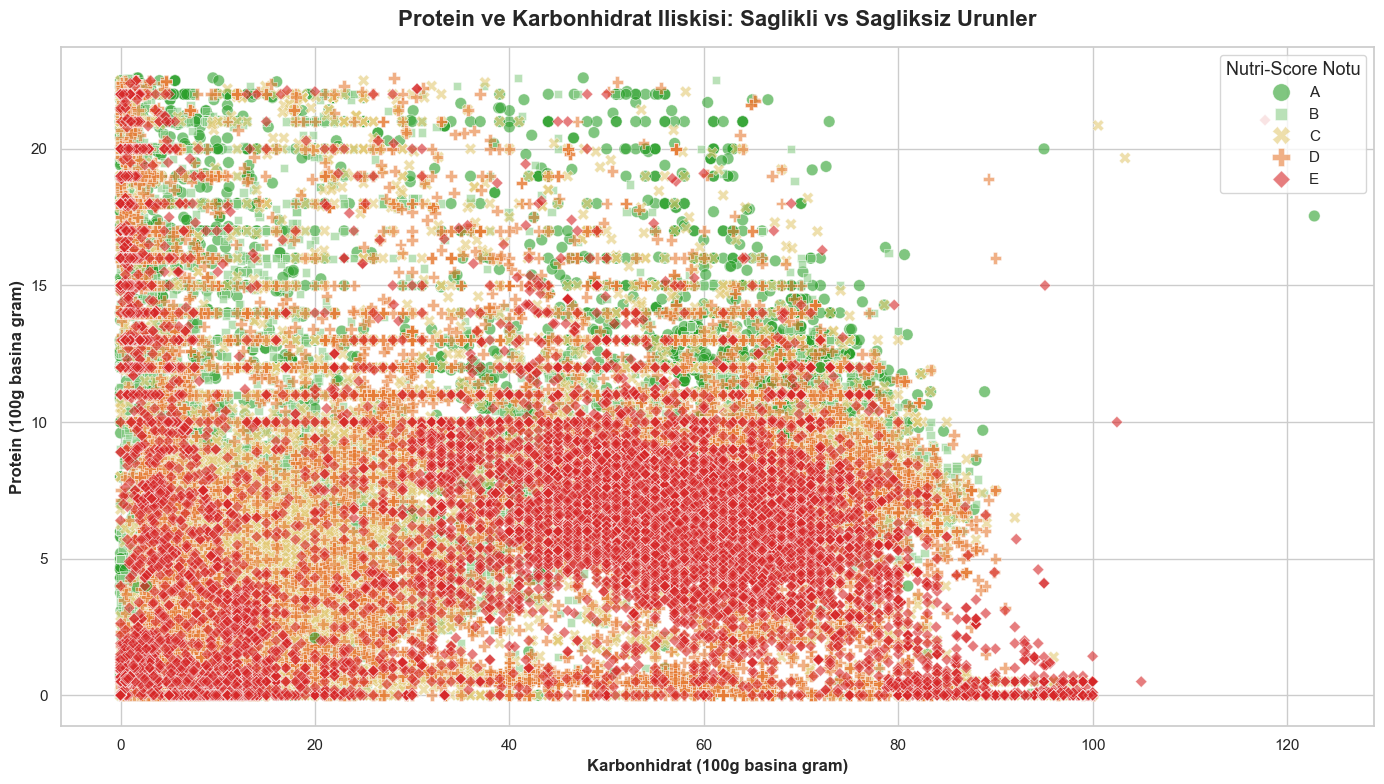

In [3]:
# Protein ve Karbonhidrat Iliskisi - IQR ile Uc Degerler Temizlendi

def iqr_filter(dataframe, column, factor=1.5):
    """IQR yontemiyle uc degerleri kaldirir."""
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    return dataframe[(dataframe[column] >= Q1 - factor * IQR) &
                     (dataframe[column] <= Q3 + factor * IQR)]

# Nutri-Score notlarini temizle (Sadece A-E arasi olanlari al)
df_plot = df.copy()
df_filtered = df_plot[df_plot['nutriscore_notu'].isin(['A', 'B', 'C', 'D', 'E'])]

# IQR filtresi: protein ve karbonhidrat icin uc degerleri temizle
df_clean = iqr_filter(df_filtered, 'karbonhidrat_g', factor=1.5)
df_clean = iqr_filter(df_clean,    'protein_g',      factor=1.5)

print(f'Temizleme oncesi: {len(df_filtered)} satir')
print(f'Temizleme sonrasi: {len(df_clean)} satir ({len(df_filtered)-len(df_clean)} uc deger kaldirildi)')

score_order = ['A', 'B', 'C', 'D', 'E']
custom_palette = ['#2ca02c', '#8cce8a', '#e3ca76', '#e67c35', '#d62728']

plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=df_clean,
    x='karbonhidrat_g',
    y='protein_g',
    hue='nutriscore_notu',
    hue_order=score_order,
    palette=custom_palette,
    style='nutriscore_notu',
    s=70,
    alpha=0.6,
    edgecolor='w',
    linewidth=0.5
)

plt.title('Protein ve Karbonhidrat Iliskisi: Saglikli vs Sagliksiz Urunler', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Karbonhidrat (100g basina gram)', fontsize=12, fontweight='bold')
plt.ylabel('Protein (100g basina gram)', fontsize=12, fontweight='bold')
plt.legend(title='Nutri-Score Notu', title_fontsize='13', fontsize='11', loc='upper right', markerscale=1.5)
plt.tight_layout()
plt.show()


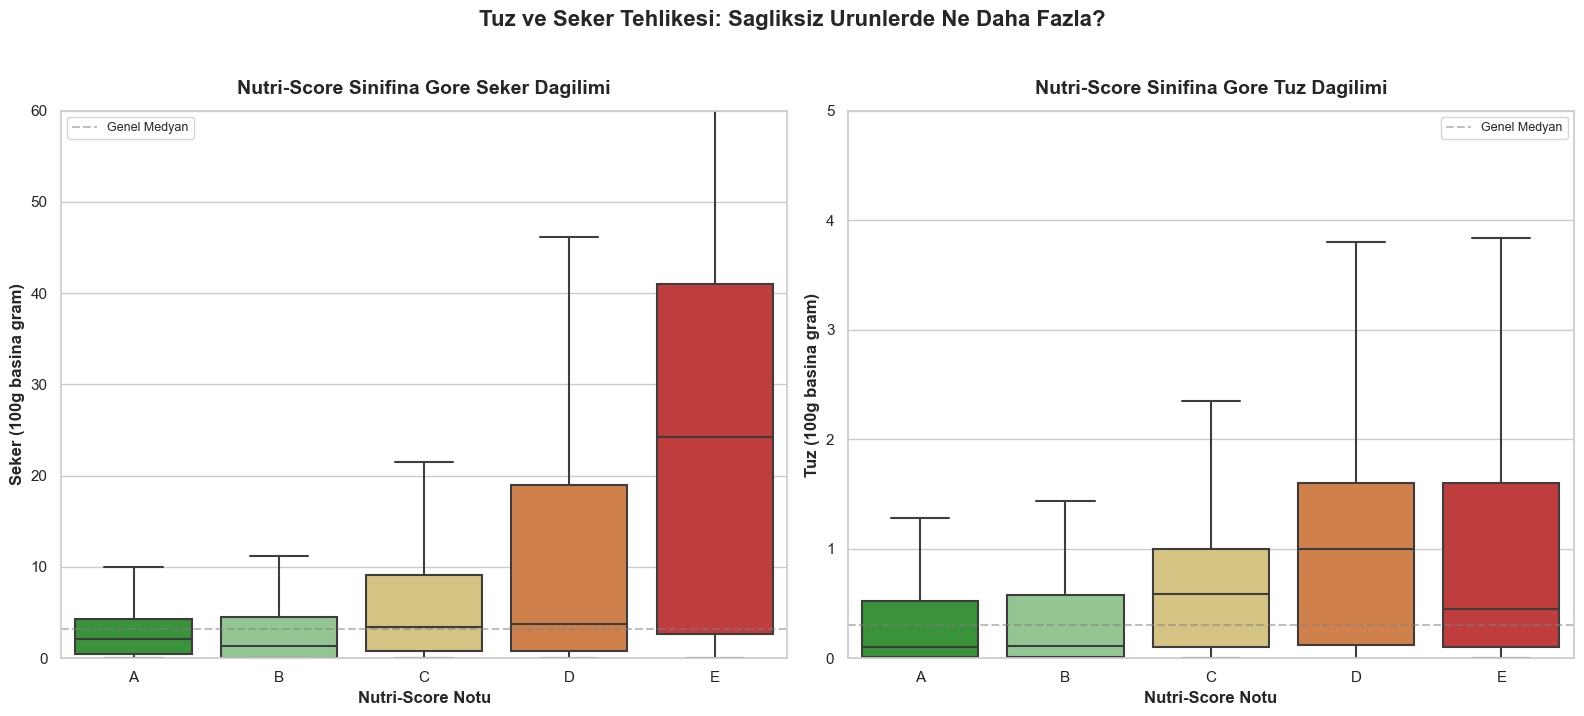

In [4]:
# Tuz ve Seker Tehlikesi: Nutri-Score Sinifina Gore Dagilim
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Nutri-Score notlarini temizle (Sadece A-E arasi olanlari al)
df_filtered = df[df['nutriscore_notu'].isin(['A', 'B', 'C', 'D', 'E'])].copy()

score_order = ['A', 'B', 'C', 'D', 'E']
custom_palette = ['#2ca02c', '#8cce8a', '#e3ca76', '#e67c35', '#d62728']

# --- SOL GRAFIK: SEKER ---
sns.boxplot(
    data=df_filtered,
    x='nutriscore_notu',
    y='seker_g',
    order=score_order,
    palette=custom_palette,
    showfliers=False,
    ax=axes[0],
    linewidth=1.5
)
axes[0].set_title('Nutri-Score Sinifina Gore Seker Dagilimi', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Nutri-Score Notu', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Seker (100g basina gram)', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 60)
axes[0].axhline(y=df_filtered['seker_g'].median(), color='gray', linestyle='--', alpha=0.5, label='Genel Medyan')
axes[0].legend(fontsize=9)

# --- SAG GRAFIK: TUZ ---
sns.boxplot(
    data=df_filtered,
    x='nutriscore_notu',
    y='tuz_g',
    order=score_order,
    palette=custom_palette,
    showfliers=False,
    ax=axes[1],
    linewidth=1.5
)
axes[1].set_title('Nutri-Score Sinifina Gore Tuz Dagilimi', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Nutri-Score Notu', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tuz (100g basina gram)', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 5)
axes[1].axhline(y=df_filtered['tuz_g'].median(), color='gray', linestyle='--', alpha=0.5, label='Genel Medyan')
axes[1].legend(fontsize=9)

fig.suptitle('Tuz ve Seker Tehlikesi: Sagliksiz Urunlerde Ne Daha Fazla?', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


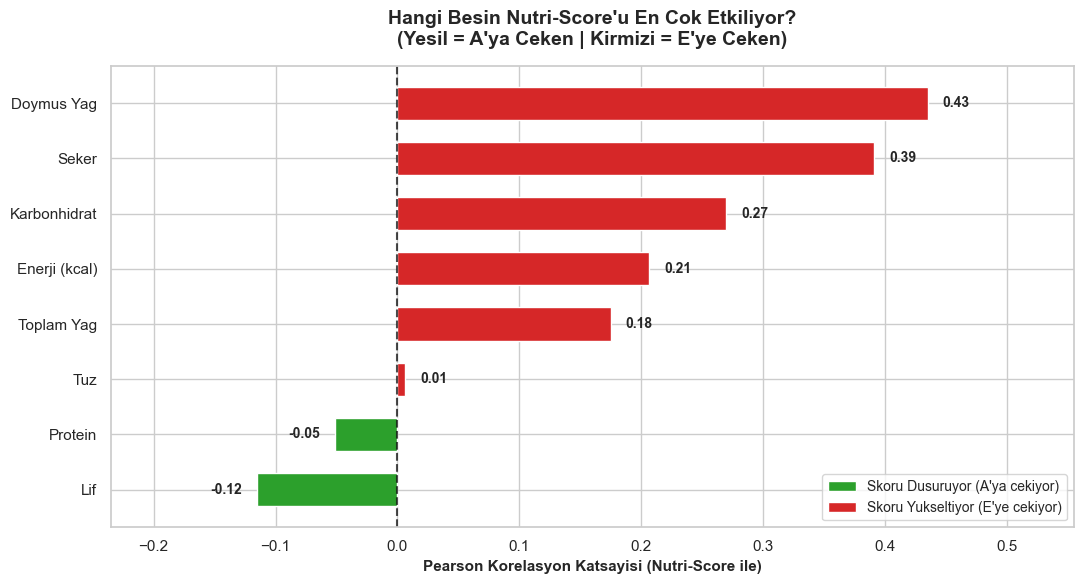

In [5]:
# Besin Degerlerinin Nutri-Score ile Korelasyonu (Horizontal Barplot)

besin_kolonlari = [
    'enerji_kcal', 'yag_g', 'doymus_yag_g',
    'karbonhidrat_g', 'seker_g', 'lif_g',
    'protein_g', 'tuz_g'
]

# nutriscore_notu'yu sayisala cevir (A=0, B=1, C=2, D=3, E=4)
df_corr = df[besin_kolonlari + ['nutriscore_notu']].copy()
score_mapping = {'A': 0.0, 'B': 1.0, 'C': 2.0, 'D': 3.0, 'E': 4.0}
df_corr['nutriscore_notu'] = df_corr['nutriscore_notu'].map(score_mapping)
df_corr = df_corr.dropna(subset=['nutriscore_notu'])

# Pearson korelasyonunu hesapla ve sirala
corr_series = df_corr.corr(method='pearson')['nutriscore_notu'].drop('nutriscore_notu')
corr_sorted = corr_series.sort_values()

# Kolon isimlerini okunaklı hale getir
label_map = {
    'enerji_kcal'   : 'Enerji (kcal)',
    'yag_g'         : 'Toplam Yag',
    'doymus_yag_g'  : 'Doymus Yag',
    'karbonhidrat_g': 'Karbonhidrat',
    'seker_g'       : 'Seker',
    'lif_g'         : 'Lif',
    'protein_g'     : 'Protein',
    'tuz_g'         : 'Tuz'
}
corr_sorted.index = [label_map.get(i, i) for i in corr_sorted.index]

# Renk: negatif -> yesil, pozitif -> kirmizi
colors = ['#2ca02c' if v < 0 else '#d62728' for v in corr_sorted.values]

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    corr_sorted.index,
    corr_sorted.values,
    color=colors,
    edgecolor='white',
    height=0.6
)

# Cubuk uclarina deger yaz
for bar, val in zip(bars, corr_sorted.values):
    offset = 0.012 if val >= 0 else -0.012
    ha = 'left' if val >= 0 else 'right'
    ax.text(
        val + offset,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}',
        va='center', ha=ha, fontsize=10, fontweight='bold'
    )

# Sifir noktasi kesik cizgi
ax.axvline(x=0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)

ax.set_title(
    "Hangi Besin Nutri-Score'u En Cok Etkiliyor?\n"
    "(Yesil = A'ya Ceken | Kirmizi = E'ye Ceken)",
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Pearson Korelasyon Katsayisi (Nutri-Score ile)', fontsize=11, fontweight='bold')
ax.set_xlim(corr_sorted.min() - 0.12, corr_sorted.max() + 0.12)
ax.tick_params(axis='y', labelsize=11)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ca02c', label="Skoru Dusuruyor (A'ya cekiyor)"),
    Patch(facecolor='#d62728', label="Skoru Yukseltiyor (E'ye cekiyor)")
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()
